In [25]:
import pandas as pd 

df_cleaned = pd.read_csv('../data/data_cleaned.csv', low_memory=False)
df_cleaned.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,profession_clean,party_clean
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,Other,Other
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,Health,Union pour une nouvelle majorité
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,Health,Union pour une nouvelle majorité
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,Education,Other
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,Other,Union pour une nouvelle majorité


In [26]:
df_cleaned.shape

(3596, 12)

In [27]:
df_cleaned['text']

0       Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...
1       Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...
2       REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...
3       ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...
4       Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...
                              ...                        
3591    Philippe DECRULLE 39 ans, Marié Navigant comme...
3592    Sciences Po / fonds CEVIPOF\nÉLECTIONS LÉGISLA...
3593    Sciences Po / fonds CEVIPOF\nElections législa...
3594    Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...
3595    Sciences Po / fonds CEVIPOF\nÉlections législa...
Name: text, Length: 3596, dtype: str

In [28]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords


# Load French stopwords
french_stopwords = stopwords.words('french')

vectorizer_temp = CountVectorizer(
    stop_words=french_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',  # keep words ≥3 letters
    max_df=1.0,
    min_df=5
)

X_temp = vectorizer_temp.fit_transform(df_cleaned['text'])

terms = vectorizer_temp.get_feature_names_out()

doc_freq = np.asarray((X_temp > 0).sum(axis=0)).flatten()

doc_freq_ratio = doc_freq / X_temp.shape[0]

terms_df = pd.DataFrame({
    "term": terms,
    "doc_frequency": doc_freq,
    "doc_freq_ratio": doc_freq_ratio
})

top_words = terms_df.sort_values("doc_freq_ratio", ascending=False)
top_words.head(50)



,term,doc_frequency,doc_freq_ratio
11508,sciences,3596,1.000000
5254,fonds,3596,1.000000
2006,cevipof,3593,0.999166
2241,circonscription,3235,0.899611
1838,candidat,2898,0.805895
5347,france,2728,0.758621
673,ans,2604,0.724138
6831,juin,2472,0.687430
9297,politique,2456,0.682981
9263,plus,2448,0.680756


In [29]:
high_freq_words = terms_df[terms_df['doc_freq_ratio'] > 0.4]['term'].tolist()

print("High-frequency candidate stopwords:")
print(high_freq_words[:50])

High-frequency candidate stopwords:
['ans', 'assemblée', 'aujourd', 'avenir', 'candidat', 'candidats', 'cette', 'ceux', 'cevipof', 'chômage', 'circonscription', 'comme', 'confiance', 'conseiller', 'contre', 'depuis', 'député', 'elections', 'emploi', 'enfants', 'entre', 'faire', 'fait', 'faut', 'fonds', 'france', 'français', 'française', 'françois', 'gauche', 'hui', 'jean', 'juin', 'leurs', 'liberté', 'législatives', 'majorité', 'mitterrand', 'monde', 'national', 'nationale', 'nouvelle', 'parti', 'pays', 'plus', 'politique', 'président', 'rassemblement', 'république', 'sans']


In [30]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords

extra_stopwords = {

    # Archive artifacts
    "cevipof","fonds",

    # Election formatting
    "circonscription","elections","législatives","juin","mars","tour",

    # Candidate biography
    "candidat","candidats","conseiller","député","président",
    "maire","suppléant","jean","michel","ans",

    # Weak rhetorical words
    "comme","contre","faire","fait","faut","plus",
    "cette","ceux","leurs","depuis","tout","tous",

    # German OCR artifacts
    "die","der","und","für","den","sie","eine","das","wir","werden",'auf', 'nicht', 'einer', 'dass',
    'alsace', 'strasbourg', 'gegen', 'ihr', 'wählen', 'wollen', 'auch',
        
    # Remaining German OCR artifacts
    "mit","von","ist","dem","ein","ich","sich","wird","haben","durch","ihre",

    # Additional formatting / weak tokens seen in topics
    "mai","général","toutes"
}

french_stopwords = set(stopwords.words('french'))

all_stopwords = list(french_stopwords.union(extra_stopwords))

vectorizer = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',
    max_df=0.85,
    min_df=15
)

X = vectorizer.fit_transform(df_cleaned['text'])

terms = vectorizer.get_feature_names_out()

X.shape

(3596, 6753)

In [31]:
# Train first LDA model

from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method='batch'
)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",10
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [32]:
# show top words for topic
import numpy as np

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_features = np.argsort(topic)[::-1][:n_top_words]
        words = [feature_names[i] for i in top_features]
        print(f"Topic {topic_idx}: {words}")

print_topics(lda, terms)

Topic 0: ['droite', 'gauche', 'communiste', 'politique', 'parti', 'forces', 'communistes', 'être', 'voix', 'rassemblement']
Topic 1: ['être', 'politique', 'sans', 'temps', 'société', 'parce', 'travail', 'vie', 'bien', 'aussi']
Topic 2: ['écologie', 'entente', 'ecologistes', 'vie', 'verts', 'écologistes', 'environnement', 'ecologie', 'politique', 'assemblée']
Topic 3: ['france', 'majorité', 'union', 'parti', 'socialiste', 'françois', 'changement', 'république', 'français', 'mitterrand']
Topic 4: ['national', 'front', 'vote', 'nationale', 'rpr', 'udf', 'avenir', 'force', 'france', 'votez']
Topic 5: ['gauche', 'sans', 'parti', 'politique', 'autre', 'socialiste', 'droite', 'voter', 'europe', 'vraiment']
Topic 6: ['metz', 'moselle', 'belfort', 'nucléaire', 'vosges', 'toute', 'lorraine', 'orne', 'écologistes', 'centrale']
Topic 7: ['gauche', 'politique', 'femmes', 'nouvelle', 'place', 'majorité', 'populaire', 'nucléaire', 'travailleurs', 'travail']
Topic 8: ['politique', 'france', 'économie'

In [33]:
from sklearn.decomposition import LatentDirichletAllocation

topic_numbers = [5, 8, 10, 12, 15, 20]

lda_models = {}
perplexities = []

for k in topic_numbers:
    
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch'
    )
    
    lda.fit(X)
    
    lda_models[k] = lda
    
    perplexities.append(lda.perplexity(X))

print("Perplexities:", perplexities)

Perplexities: [np.float64(1623.0918087740647), np.float64(1546.0295842896028), np.float64(1527.2698243194368), np.float64(1501.2464675575654), np.float64(1458.144012520091), np.float64(1457.4694984428672)]


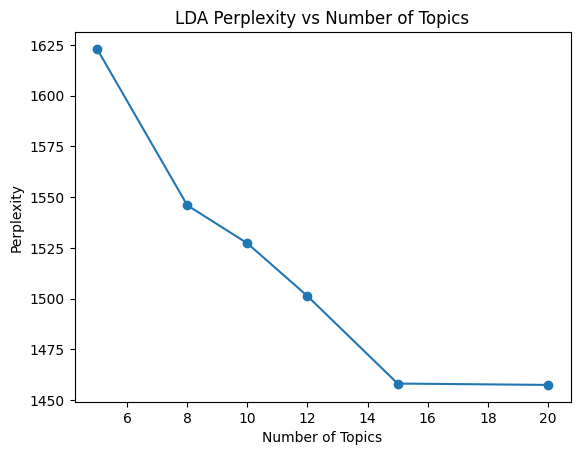

In [34]:
import matplotlib.pyplot as plt

plt.plot(topic_numbers, perplexities, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Perplexity")
plt.title("LDA Perplexity vs Number of Topics")
plt.show()

In [35]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

texts = [
    doc.split()
    for doc in df_cleaned['text']
]

dictionary = Dictionary(texts)

coherence_scores = []

for k in topic_numbers:
    
    lda_model = lda_models[k]
    
    topics = [
        [terms[i] for i in topic.argsort()[-10:]]
        for topic in lda_model.components_
    ]
    
    coherence_model = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    coherence_scores.append(coherence_model.get_coherence())

print(coherence_scores)

[np.float64(0.4319380666369191), np.float64(0.39655167267845226), np.float64(0.3934391485090597), np.float64(0.3917484435452923), np.float64(0.3652827160097086), np.float64(0.42023713437556226)]


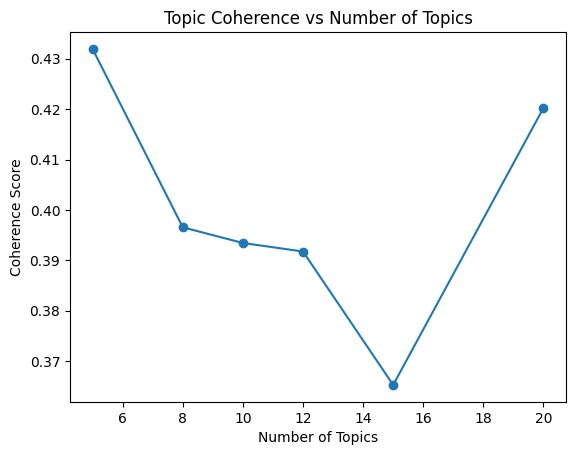

In [36]:
plt.plot(topic_numbers, coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.show()

In [37]:
from sklearn.decomposition import LatentDirichletAllocation

lda_final = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method='batch'
)

lda_final.fit(X)

doc_topic = lda_final.transform(X)

print(doc_topic.shape)


(3596, 10)


In [38]:
import pandas as pd

topic_columns = [f"Topic_{i}" for i in range(10)]

topic_df = pd.DataFrame(doc_topic, columns=topic_columns)

topic_df.head()

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,0.147503,0.000265,0.000265,0.850380,0.000265,0.000265,0.000265,0.000265,0.000265,0.000265
1,0.000392,0.000392,0.000392,0.390756,0.000392,0.000392,0.000392,0.000392,0.000392,0.606106
2,0.000283,0.000283,0.000283,0.485948,0.000283,0.025883,0.000283,0.000283,0.000283,0.486186
3,0.169404,0.000714,0.000714,0.408238,0.000715,0.000714,0.000714,0.193019,0.000714,0.225052
4,0.000547,0.000547,0.000547,0.459253,0.000547,0.000547,0.000547,0.000547,0.000547,0.536374


In [39]:
df_topics = pd.concat(
    [df_cleaned.reset_index(drop=True), topic_df],
    axis=1
)

print(df_topics.head().to_string())

                               id        date                   titulaire-liste titulaire-profession titulaire-age-calcule titulaire-sexe departement-insee                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [40]:
doc_topic[0].sum()

np.float64(1.0000000000000002)

In [41]:
import numpy as np

def print_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[-n_top_words:][::-1]]
        print(f"Topic {topic_idx}: {words}")

print_topics(lda_final, terms)

Topic 0: ['droite', 'gauche', 'communiste', 'politique', 'parti', 'forces', 'communistes', 'être', 'voix', 'rassemblement']
Topic 1: ['être', 'politique', 'sans', 'temps', 'société', 'parce', 'travail', 'vie', 'bien', 'aussi']
Topic 2: ['écologie', 'entente', 'ecologistes', 'vie', 'verts', 'écologistes', 'environnement', 'ecologie', 'politique', 'assemblée']
Topic 3: ['france', 'majorité', 'union', 'parti', 'socialiste', 'françois', 'changement', 'république', 'français', 'mitterrand']
Topic 4: ['national', 'front', 'vote', 'nationale', 'rpr', 'udf', 'avenir', 'force', 'france', 'votez']
Topic 5: ['gauche', 'sans', 'parti', 'politique', 'autre', 'socialiste', 'droite', 'voter', 'europe', 'vraiment']
Topic 6: ['metz', 'moselle', 'belfort', 'nucléaire', 'vosges', 'toute', 'lorraine', 'orne', 'écologistes', 'centrale']
Topic 7: ['gauche', 'politique', 'femmes', 'nouvelle', 'place', 'majorité', 'populaire', 'nucléaire', 'travailleurs', 'travail']
Topic 8: ['politique', 'france', 'économie'

In [42]:
df_topics[[f"Topic_{i}" for i in range(10)]].mean().sort_values(ascending=False)

Topic_3    0.318589
Topic_9    0.206649
Topic_4    0.124974
Topic_2    0.104793
Topic_0    0.088847
Topic_1    0.049335
Topic_7    0.044759
Topic_5    0.029245
Topic_8    0.027392
Topic_6    0.005418
dtype: float64

In [43]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words=all_stopwords,
    token_pattern=r'\b[a-zA-ZÀ-ÿ]{3,}\b',
    max_df=0.9,
    min_df=10
)

embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

docs = df_cleaned["text"].astype(str).tolist()

topics, probs = topic_model.fit_transform(docs)



Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9531.53it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-05 21:15:59,083 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 113/113 [00:16<00:00,  6.81it/s]
2026-03-05 21:16:15,866 - BERTopic - Embedding - Completed ✓
2026-03-05 21:16:15,866 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-05 21:16:22,724 - BERTopic - Dimensionality - Completed ✓
2026-03-05 21:16:22,725 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-05 21:16:22,847 - BERTopic - Cluster - Completed ✓
2026-03-05 21:16:22,848 - BERTopic - Representation - Fine-tuning topics 

In [44]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,95,-1_front_rpr_udf_populaire,"[front, rpr, udf, populaire, convictions, vive...",[Sciences Po / fonds CEVIPOF\n7 raisons de vot...
1,0,2546,0_gauche_politique_parti_droite,"[gauche, politique, parti, droite, union, être...",[Sciences Po / fonds CEVIPOF\nELECTIONS LEGISL...
2,1,462,1_écologie_entente_environnement_vie,"[écologie, entente, environnement, vie, monde,...",[ENTENTE DES ECOLOGISTES\nELECTIONS LEGISLATIV...
3,2,71,2_front_rpr_udf_vive,"[front, rpr, udf, vive, convictions, jusqu, ic...",[7 raisons de voter pour le candidat du Front ...
4,3,68,3_front_rpr_udf_convictions,"[front, rpr, udf, convictions, vive, ici, fait...",[Sciences Po / fonds CEVIPOF\n7 raisons de vot...
5,4,48,4_front_rpr_udf_vive,"[front, rpr, udf, vive, convictions, jusqu, po...",[Sciences Po / fonds CEVIPOF\nMaintenant la fo...
6,5,44,5_front_rpr_udf_convictions,"[front, rpr, udf, convictions, vive, jusqu, ic...",[7 raisons de voter pour le candidat du Front ...
7,6,42,6_front_rpr_udf_convictions,"[front, rpr, udf, convictions, vive, jusqu, ic...",[7 raisons de voter pour le candidat du Front ...
8,7,26,7_défense_place_formation_etat,"[défense, place, formation, etat, populaire, p...",[alliance populaire\nCANDIDAT DE RASSEMBLEMENT...
9,8,25,8_écologie_entente_environnement_vie,"[écologie, entente, environnement, vie, projet...",[Sciences Po / fonds CEVIPOF\nENTENTE DES ECOL...


In [45]:
topic_model.get_topic(0)

[('gauche', np.float64(0.02882204195991652)),
 ('politique', np.float64(0.028197515877815625)),
 ('parti', np.float64(0.026719257584951722)),
 ('droite', np.float64(0.025875992753528393)),
 ('union', np.float64(0.02323060338472016)),
 ('être', np.float64(0.02218819732233986)),
 ('socialiste', np.float64(0.02068422702686438)),
 ('sociale', np.float64(0.01989012816034273)),
 ('nouvelle', np.float64(0.019507988261363896)),
 ('françois', np.float64(0.01942950791634953))]

In [46]:
topic_model.visualize_barchart()

In [ ]:
# # save data
# df_topics.to_csv("../data/data_manifesto_topics.csv", index=False)